# Real Data Price Prediction Test — Hierarchy Features vs Baseline

This notebook tests the idea on real market data using `yfinance`.

It compares:

1. naive persistence baseline;
2. ordinary price/volume feature model;
3. hierarchy-augmented model using greed/fear indices and hierarchy leaf memberships.

The notebook predicts:

- future close price after `HORIZON` trading days;
- future return after `HORIZON` trading days;
- future direction: up/down.

Important caution: this is a research notebook, not a trading system.

In [1]:
# If needed, run this once:
# !pip install yfinance numpy pandas matplotlib scikit-learn torch

import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TICKER = "SPY"
START_DATE = "2010-01-01"
END_DATE = None
HORIZON = 5
TEST_FRACTION = 0.20
VALIDATION_FRACTION = 0.15

## Load real market data

Default asset: `SPY`.

You can change `TICKER` to another symbol such as:

- `AAPL`
- `MSFT`
- `NVDA`
- `BTC-USD`
- `ETH-USD`
- `QQQ`

In [2]:
def load_yfinance_ohlcv(ticker: str, start_date: str, end_date: Optional[str] = None) -> pd.DataFrame:
    raw = yf.download(
        tickers=ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False,
        group_by="column",
    )

    if raw.empty:
        raise RuntimeError(f"No data returned for ticker: {ticker}")

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [col[0].lower() for col in raw.columns]
    else:
        raw.columns = [str(col).lower() for col in raw.columns]

    required = ["open", "high", "low", "close", "volume"]
    missing = [col for col in required if col not in raw.columns]
    if missing:
        raise RuntimeError(f"Missing required columns: {missing}")

    df = raw[required].copy()
    df = df.reset_index()
    df = df.rename(columns={"Date": "date", "Datetime": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.dropna().reset_index(drop=True)
    return df

df = load_yfinance_ohlcv(TICKER, START_DATE, END_DATE)
df.head(), df.tail(), df.shape

(        date       open       high        low      close     volume
 0 2010-01-04  84.078083  84.841271  83.434609  84.796379  118944600
 1 2010-01-05  84.743981  85.058234  84.437206  85.020821  111579900
 2 2010-01-06  84.938516  85.290183  84.871179  85.080681  116074400
 3 2010-01-07  84.923565  85.544593  84.684133  85.439842  131091100
 4 2010-01-08  85.215373  85.761580  85.043285  85.724167  126402800,
            date        open        high         low       close    volume
 4108 2026-05-05  721.770020  725.039978  721.489990  723.770020  36933200
 4109 2026-05-06  728.159973  734.590027  727.820007  733.830017  53288900
 4110 2026-05-07  735.049988  736.130005  729.750000  731.580017  51724600
 4111 2026-05-08  734.929993  738.080017  734.570007  737.619995  47227100
 4112 2026-05-11  736.450012  740.789978  736.450012  739.299988  43945400,
 (4113, 6))

## Feature construction

These features are deliberately simple.

The point is not to win a trading competition.
The point is to test whether hierarchy-derived representation adds information beyond ordinary market features.

In [3]:
def rolling_zscore(x: pd.Series, window: int, eps: float = 1e-8) -> pd.Series:
    mean = x.rolling(window, min_periods=max(3, window // 3)).mean()
    std = x.rolling(window, min_periods=max(3, window // 3)).std()
    return (x - mean) / (std + eps)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def make_real_market_features(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    out = df.copy()

    out["ret_1"] = out["close"].pct_change(1)
    out["ret_2"] = out["close"].pct_change(2)
    out["ret_5"] = out["close"].pct_change(5)
    out["ret_10"] = out["close"].pct_change(10)
    out["ret_20"] = out["close"].pct_change(20)

    out["range_pct"] = (out["high"] - out["low"]) / out["close"]
    out["open_close_pct"] = (out["close"] - out["open"]) / out["open"]

    out["vol_5"] = out["ret_1"].rolling(5).std()
    out["vol_10"] = out["ret_1"].rolling(10).std()
    out["vol_20"] = out["ret_1"].rolling(20).std()

    out["ma_10"] = out["close"].rolling(10).mean()
    out["ma_20"] = out["close"].rolling(20).mean()
    out["ma_50"] = out["close"].rolling(50).mean()

    out["price_to_ma_10"] = out["close"] / out["ma_10"] - 1.0
    out["price_to_ma_20"] = out["close"] / out["ma_20"] - 1.0
    out["price_to_ma_50"] = out["close"] / out["ma_50"] - 1.0

    out["volume_log"] = np.log1p(out["volume"])
    out["volume_z_20"] = rolling_zscore(out["volume_log"], 20)

    out["rolling_max_20"] = out["close"].rolling(20).max()
    out["rolling_max_50"] = out["close"].rolling(50).max()
    out["drawdown_20"] = out["close"] / out["rolling_max_20"] - 1.0
    out["drawdown_50"] = out["close"] / out["rolling_max_50"] - 1.0

    out["trend_pressure"] = rolling_zscore(out["ret_10"], 30)

    out["fear_pressure"] = (
        -4.0 * out["drawdown_20"]
        -2.0 * out["drawdown_50"]
        + 8.0 * out["vol_10"]
        + 0.35 * out["volume_z_20"]
        - 0.50 * out["ret_5"]
    )

    out["greed_pressure"] = (
        1.50 * out["trend_pressure"]
        + 2.00 * out["price_to_ma_20"]
        + 1.00 * out["ret_20"]
        + 0.20 * out["volume_z_20"]
        - 3.00 * out["vol_20"]
    )

    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))

    out["future_close"] = out["close"].shift(-horizon)
    out["future_return"] = out["future_close"] / out["close"] - 1.0
    out["future_direction"] = (out["future_return"] > 0).astype(int)

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna().reset_index(drop=True)
    return out

features_df = make_real_market_features(df, HORIZON)
features_df.head(), features_df.shape

(        date       open       high        low      close     volume     ret_1  \
 0 2010-03-16  86.651989  87.183229  86.412557  87.100929  168673000  0.007966   
 1 2010-03-17  87.362786  87.901509  87.108386  87.617180  177468100  0.005927   
 2 2010-03-18  87.624664  87.744377  87.220622  87.572289  196509100 -0.000512   
 3 2010-03-19  87.129036  88.120761  86.790945  87.129036  226641100 -0.005062   
 4 2010-03-22  86.633184  87.752636  86.580593  87.594856  184477800  0.005346   
 
       ret_2     ret_5    ret_10  ...  drawdown_20  drawdown_50  \
 0  0.008228  0.017037  0.037523  ...     0.000000     0.000000   
 1  0.013940  0.018526  0.042742  ...     0.000000     0.000000   
 2  0.005412  0.013772  0.039063  ...    -0.000512    -0.000512   
 3 -0.005571  0.008554  0.019235  ...    -0.005571    -0.005571   
 4  0.000258  0.013682  0.024505  ...    -0.000255    -0.000255   
 
    trend_pressure  fear_pressure  greed_pressure  fear_index  greed_index  \
 0        0.847894      

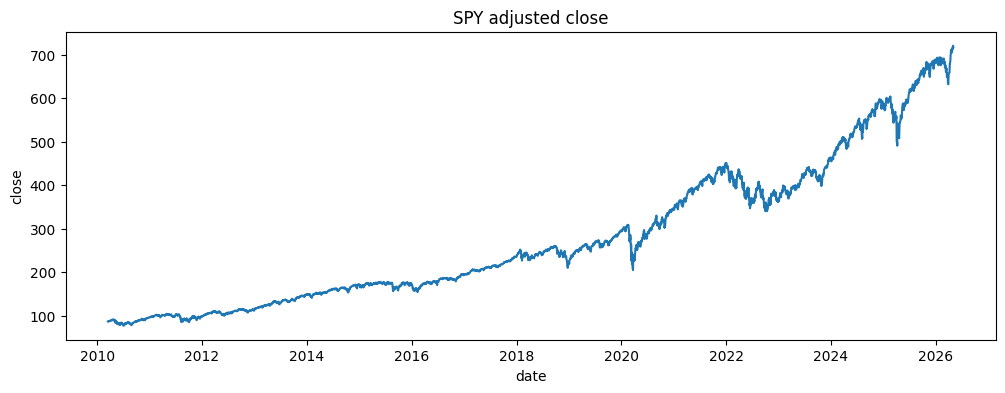

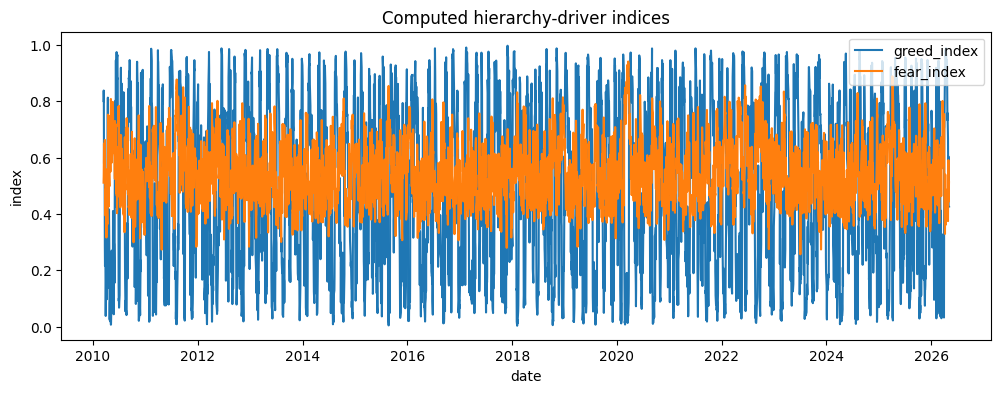

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(features_df["date"], features_df["close"])
plt.title(f"{TICKER} adjusted close")
plt.xlabel("date")
plt.ylabel("close")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(features_df["date"], features_df["greed_index"], label="greed_index")
plt.plot(features_df["date"], features_df["fear_index"], label="fear_index")
plt.title("Computed hierarchy-driver indices")
plt.xlabel("date")
plt.ylabel("index")
plt.legend()
plt.show()

## Build hierarchy leaf memberships

This creates a tree over the greed/fear plane and converts each observation into a soft membership vector.

In [5]:
@dataclass
class MeasureNode:
    node_id: str
    depth: int
    bounds: Dict[str, Tuple[float, float]]
    mass: float
    count: int
    mean: Dict[str, float]
    children: Optional[List["MeasureNode"]] = None

    @property
    def is_leaf(self) -> bool:
        return not self.children

def in_bounds(row: pd.Series, bounds: Dict[str, Tuple[float, float]]) -> bool:
    for col, (lo, hi) in bounds.items():
        value = float(row[col])
        if not (lo <= value < hi):
            return False
    return True

def split_node(node: MeasureNode, split_col: str, split_value: float) -> List[MeasureNode]:
    lo, hi = node.bounds[split_col]
    left_bounds = dict(node.bounds)
    right_bounds = dict(node.bounds)
    left_bounds[split_col] = (lo, split_value)
    right_bounds[split_col] = (split_value, hi)

    left = MeasureNode(node.node_id + "L", node.depth + 1, left_bounds, node.mass / 2.0, 0, {}, None)
    right = MeasureNode(node.node_id + "R", node.depth + 1, right_bounds, node.mass / 2.0, 0, {}, None)
    node.children = [left, right]
    return node.children

def collect_leaves(node: MeasureNode) -> List[MeasureNode]:
    if node.is_leaf:
        return [node]
    leaves = []
    for child in node.children:
        leaves.extend(collect_leaves(child))
    return leaves

def build_hierarchy_from_training_data(train_df: pd.DataFrame, max_depth: int = 4, min_count: int = 80) -> MeasureNode:
    feature_cols = ["greed_index", "fear_index"]

    root = MeasureNode(
        node_id="root",
        depth=0,
        bounds={"greed_index": (0.0, 1.000001), "fear_index": (0.0, 1.000001)},
        mass=1.0,
        count=len(train_df),
        mean={col: float(train_df[col].mean()) for col in feature_cols},
        children=None,
    )

    queue = [root]
    while queue:
        node = queue.pop(0)
        if node.depth >= max_depth:
            continue

        mask = train_df.apply(lambda row: in_bounds(row, node.bounds), axis=1)
        subset = train_df[mask]
        node.count = len(subset)
        node.mass = node.count / max(len(train_df), 1)

        if node.count < min_count:
            continue

        variances = {col: float(subset[col].var()) for col in feature_cols}
        split_col = max(variances, key=variances.get)
        split_value = float(subset[split_col].median())

        if node.bounds[split_col][0] < split_value < node.bounds[split_col][1]:
            queue.extend(split_node(node, split_col, split_value))

    for leaf in collect_leaves(root):
        mask = train_df.apply(lambda row: in_bounds(row, leaf.bounds), axis=1)
        subset = train_df[mask]
        leaf.count = len(subset)
        leaf.mass = leaf.count / max(len(train_df), 1)
        leaf.mean = {
            col: float(subset[col].mean()) if len(subset) else 0.0
            for col in feature_cols
        }

    return root

def soft_membership(row: pd.Series, leaves: List[MeasureNode], temperature: float = 0.04) -> np.ndarray:
    point = np.array([float(row["greed_index"]), float(row["fear_index"])])
    centers = []
    for leaf in leaves:
        g_lo, g_hi = leaf.bounds["greed_index"]
        f_lo, f_hi = leaf.bounds["fear_index"]
        centers.append([(g_lo + g_hi) / 2.0, (f_lo + f_hi) / 2.0])
    centers = np.array(centers)

    distances = np.sum((centers - point[None, :]) ** 2, axis=1)
    logits = -distances / max(temperature, 1e-8)
    logits = logits - logits.max()
    weights = np.exp(logits)
    return weights / weights.sum()

## Time-respecting split

The hierarchy is built only from training data to avoid leakage.

In [6]:
def time_split(frame: pd.DataFrame, validation_fraction: float, test_fraction: float):
    n = len(frame)
    test_start = int(n * (1.0 - test_fraction))
    validation_start = int(test_start * (1.0 - validation_fraction))

    train_df = frame.iloc[:validation_start].copy()
    validation_df = frame.iloc[validation_start:test_start].copy()
    test_df = frame.iloc[test_start:].copy()

    return train_df, validation_df, test_df

train_df, validation_df, test_df = time_split(features_df, VALIDATION_FRACTION, TEST_FRACTION)

root = build_hierarchy_from_training_data(train_df, max_depth=4, min_count=80)
leaves = collect_leaves(root)
membership_columns = [f"leaf_{leaf.node_id}" for leaf in leaves]

def add_hierarchy_memberships(frame: pd.DataFrame, leaves: List[MeasureNode]) -> pd.DataFrame:
    membership_matrix = np.vstack([
        soft_membership(row, leaves)
        for _, row in frame.iterrows()
    ])
    membership_df = pd.DataFrame(membership_matrix, columns=membership_columns, index=frame.index)
    return pd.concat([frame.reset_index(drop=True), membership_df.reset_index(drop=True)], axis=1)

train_model_df = add_hierarchy_memberships(train_df, leaves)
validation_model_df = add_hierarchy_memberships(validation_df, leaves)
test_model_df = add_hierarchy_memberships(test_df, leaves)

leaf_summary = pd.DataFrame([{
    "node_id": leaf.node_id,
    "depth": leaf.depth,
    "mass": leaf.mass,
    "count": leaf.count,
    "mean_greed": leaf.mean.get("greed_index", 0.0),
    "mean_fear": leaf.mean.get("fear_index", 0.0),
    "greed_range": leaf.bounds["greed_index"],
    "fear_range": leaf.bounds["fear_index"],
} for leaf in leaves])

leaf_summary.sort_values("mass", ascending=False)

,node_id,depth,mass,count,mean_greed,mean_fear,greed_range,fear_range
3,rootLLRR,4,0.062704,173,0.072142,0.763847,"(0.0, 0.2011094431921031)","(0.7015896572874596, 1.000001)"
5,rootLRLR,4,0.062704,173,0.396426,0.452030,"(0.33146739095555894, 0.4647142834810858)","(0.0, 0.5293442347609931)"
7,rootLRRR,4,0.062704,173,0.387943,0.614682,"(0.31935749253734164, 0.4647142834810858)","(0.5293442347609931, 1.000001)"
9,rootRLLR,4,0.062704,173,0.665883,0.443421,"(0.6027995395615489, 0.7397515969696957)","(0.0, 0.5083594931288578)"
11,rootRLRR,4,0.062704,173,0.668969,0.579292,"(0.5944351805495767, 0.7397515969696957)","(0.5083594931288578, 1.000001)"
13,rootRRLR,4,0.062704,173,0.929125,0.433115,"(0.8728383334303123, 1.000001)","(0.0, 0.488455782044213)"
15,rootRRRR,4,0.062704,173,0.925341,0.569803,"(0.8698900976892887, 1.000001)","(0.488455782044213, 1.000001)"
0,rootLLLL,4,0.062341,172,0.126558,0.461799,"(0.0, 0.2011094431921031)","(0.0, 0.5303669700028484)"
1,rootLLLR,4,0.062341,172,0.114926,0.573481,"(0.0, 0.2011094431921031)","(0.5303669700028484, 0.6185930098893953)"
2,rootLLRL,4,0.062341,172,0.101203,0.659208,"(0.0, 0.2011094431921031)","(0.6185930098893953, 0.7015896572874596)"


## Train baseline and hierarchy-augmented models

We train both regression and classification models.

Regression predicts future return.  
Classification predicts future direction.

In [7]:
baseline_features = [
    "ret_1", "ret_2", "ret_5", "ret_10", "ret_20",
    "range_pct", "open_close_pct",
    "vol_5", "vol_10", "vol_20",
    "price_to_ma_10", "price_to_ma_20", "price_to_ma_50",
    "volume_z_20", "drawdown_20", "drawdown_50",
]

hierarchy_features = baseline_features + [
    "greed_index",
    "fear_index",
] + membership_columns

def fit_and_evaluate(feature_columns: List[str], model_name: str):
    x_train = train_model_df[feature_columns]
    y_train_reg = train_model_df["future_return"]
    y_train_cls = train_model_df["future_direction"]

    x_test = test_model_df[feature_columns]
    y_test_reg = test_model_df["future_return"]
    y_test_cls = test_model_df["future_direction"]

    reg_model = RandomForestRegressor(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=-1,
    )

    cls_model = RandomForestClassifier(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    )

    reg_model.fit(x_train, y_train_reg)
    cls_model.fit(x_train, y_train_cls)

    pred_return = reg_model.predict(x_test)
    pred_direction_from_reg = (pred_return > 0).astype(int)

    pred_direction = cls_model.predict(x_test)
    pred_direction_prob = cls_model.predict_proba(x_test)[:, 1]

    predicted_future_close = test_model_df["close"].to_numpy() * (1.0 + pred_return)
    actual_future_close = test_model_df["future_close"].to_numpy()

    naive_future_close = test_model_df["close"].to_numpy()
    naive_future_return = np.zeros_like(y_test_reg.to_numpy())

    result = {
        "model": model_name,
        "return_mae": mean_absolute_error(y_test_reg, pred_return),
        "return_rmse": math.sqrt(mean_squared_error(y_test_reg, pred_return)),
        "price_mae": mean_absolute_error(actual_future_close, predicted_future_close),
        "price_rmse": math.sqrt(mean_squared_error(actual_future_close, predicted_future_close)),
        "direction_accuracy_classifier": accuracy_score(y_test_cls, pred_direction),
        "direction_balanced_accuracy_classifier": balanced_accuracy_score(y_test_cls, pred_direction),
        "direction_accuracy_from_regression": accuracy_score(y_test_cls, pred_direction_from_reg),
        "naive_return_mae": mean_absolute_error(y_test_reg, naive_future_return),
        "naive_price_mae": mean_absolute_error(actual_future_close, naive_future_close),
    }

    predictions = test_model_df[["date", "close", "future_close", "future_return", "future_direction"]].copy()
    predictions[f"{model_name}_pred_return"] = pred_return
    predictions[f"{model_name}_pred_future_close"] = predicted_future_close
    predictions[f"{model_name}_pred_direction_classifier"] = pred_direction
    predictions[f"{model_name}_pred_direction_probability"] = pred_direction_prob
    predictions[f"{model_name}_pred_direction_from_regression"] = pred_direction_from_reg

    return result, predictions, reg_model, cls_model

baseline_result, baseline_predictions, baseline_reg, baseline_cls = fit_and_evaluate(
    baseline_features,
    "baseline"
)

hierarchy_result, hierarchy_predictions, hierarchy_reg, hierarchy_cls = fit_and_evaluate(
    hierarchy_features,
    "hierarchy"
)

results = pd.DataFrame([baseline_result, hierarchy_result])
results

,model,return_mae,return_rmse,price_mae,price_rmse,direction_accuracy_classifier,direction_balanced_accuracy_classifier,direction_accuracy_from_regression,naive_return_mae,naive_price_mae
0,baseline,0.014496,0.019240,7.783082,10.443355,0.584975,0.540638,0.609606,0.015256,8.168203
1,hierarchy,0.014567,0.019312,7.816162,10.475451,0.523399,0.497695,0.616995,0.015256,8.168203


## Compare predicted price against real future price

For visual sanity checking, we plot only the test period.

In [8]:
comparison = baseline_predictions.merge(
    hierarchy_predictions[
        [
            "date",
            "hierarchy_pred_return",
            "hierarchy_pred_future_close",
            "hierarchy_pred_direction_classifier",
            "hierarchy_pred_direction_probability",
            "hierarchy_pred_direction_from_regression",
        ]
    ],
    on="date",
    how="left",
)

comparison.tail(20)

,date,close,future_close,future_return,future_direction,baseline_pred_return,baseline_pred_future_close,baseline_pred_direction_classifier,baseline_pred_direction_probability,baseline_pred_direction_from_regression,hierarchy_pred_return,hierarchy_pred_future_close,hierarchy_pred_direction_classifier,hierarchy_pred_direction_probability,hierarchy_pred_direction_from_regression
792,2026-04-07,659.219971,694.460022,0.053457,1,0.004603,662.254259,1,0.548646,1,0.004145,661.952375,1,0.520708,1
793,2026-04-08,676.010010,699.940002,0.035399,1,-0.001240,675.171475,0,0.491000,0,-0.001663,674.885695,0,0.476509,0
794,2026-04-09,679.909973,701.659973,0.031990,1,0.000650,680.352164,1,0.508627,1,0.000831,680.475284,1,0.593980,1
795,2026-04-10,679.460022,710.140015,0.045153,1,0.001169,680.254470,1,0.567959,1,0.001510,680.486049,1,0.662531,1
796,2026-04-13,686.099976,708.719971,0.032969,1,0.000135,686.192555,1,0.551629,1,0.000789,686.641563,1,0.639549,1
797,2026-04-14,694.460022,704.080017,0.013852,1,-0.000829,693.884128,1,0.528036,0,-0.000152,694.354414,1,0.604111,0
798,2026-04-15,699.940002,711.210022,0.016101,1,-0.000978,699.255681,1,0.529672,0,-0.000515,699.579400,1,0.587360,0
799,2026-04-16,701.659973,708.450012,0.009677,1,-0.000956,700.989491,1,0.583293,0,-0.000318,701.437016,1,0.596356,0
800,2026-04-17,710.140015,713.940002,0.005351,1,-0.001146,709.326330,0,0.463402,0,-0.000812,709.563504,0,0.483432,0
801,2026-04-20,708.719971,715.169983,0.009101,1,0.001557,709.823142,1,0.613393,1,0.001748,709.958922,1,0.569227,1


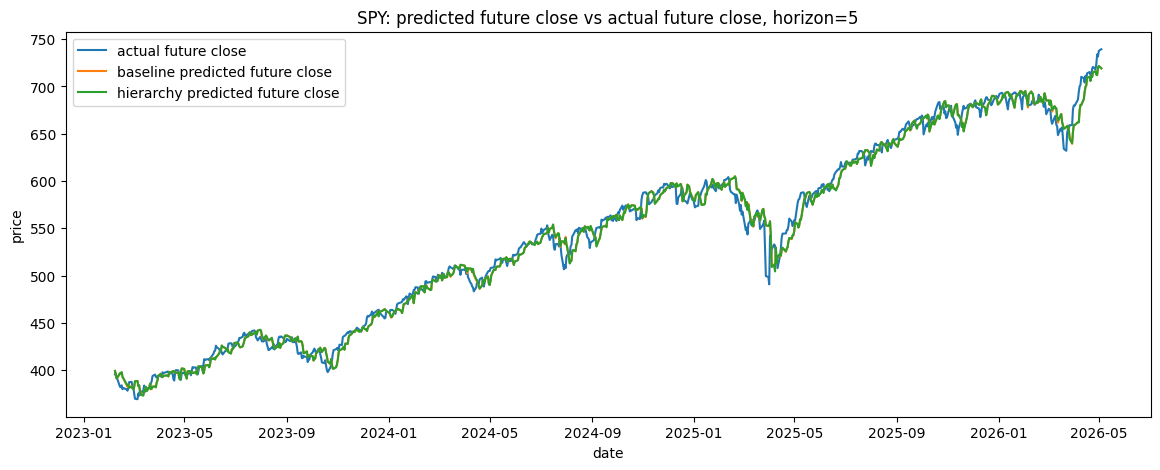

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(comparison["date"], comparison["future_close"], label="actual future close")
plt.plot(comparison["date"], comparison["baseline_pred_future_close"], label="baseline predicted future close")
plt.plot(comparison["date"], comparison["hierarchy_pred_future_close"], label="hierarchy predicted future close")
plt.title(f"{TICKER}: predicted future close vs actual future close, horizon={HORIZON}")
plt.xlabel("date")
plt.ylabel("price")
plt.legend()
plt.show()

## Directional accuracy report

This is usually more realistic than exact price prediction.

Exact future price is very difficult because most of tomorrow's price is already close to today's price.
Direction and return distribution are more informative research targets.

In [10]:
print("Baseline classifier report:")
print(classification_report(
    comparison["future_direction"],
    comparison["baseline_pred_direction_classifier"],
    digits=4,
))

print("Hierarchy classifier report:")
print(classification_report(
    comparison["future_direction"],
    comparison["hierarchy_pred_direction_classifier"],
    digits=4,
))

print("Baseline confusion matrix:")
print(confusion_matrix(
    comparison["future_direction"],
    comparison["baseline_pred_direction_classifier"],
))

print("Hierarchy confusion matrix:")
print(confusion_matrix(
    comparison["future_direction"],
    comparison["hierarchy_pred_direction_classifier"],
))

Baseline classifier report:
              precision    recall  f1-score   support

           0     0.4319    0.3675    0.3971       302
           1     0.6559    0.7137    0.6836       510

    accuracy                         0.5850       812
   macro avg     0.5439    0.5406    0.5404       812
weighted avg     0.5726    0.5850    0.5770       812

Hierarchy classifier report:
              precision    recall  f1-score   support

           0     0.3692    0.3974    0.3828       302
           1     0.6263    0.5980    0.6118       510

    accuracy                         0.5234       812
   macro avg     0.4978    0.4977    0.4973       812
weighted avg     0.5307    0.5234    0.5266       812

Baseline confusion matrix:
[[111 191]
 [146 364]]
Hierarchy confusion matrix:
[[120 182]
 [205 305]]


## Simple prediction-conditioned return analysis

This is not a trading strategy.
It only checks whether predicted probabilities are ordered meaningfully.

If the model is useful, high predicted-up probability buckets should have better realized returns than low predicted-up probability buckets.

In [11]:
def probability_bucket_report(predictions: pd.DataFrame, probability_column: str, n_bins: int = 5) -> pd.DataFrame:
    temp = predictions.copy()
    temp["probability_bucket"] = pd.qcut(
        temp[probability_column],
        q=n_bins,
        duplicates="drop",
    )

    report = temp.groupby("probability_bucket", observed=True).agg(
        count=("future_return", "size"),
        mean_future_return=("future_return", "mean"),
        median_future_return=("future_return", "median"),
        up_rate=("future_direction", "mean"),
        mean_probability=(probability_column, "mean"),
    ).reset_index()

    return report

baseline_bucket_report = probability_bucket_report(comparison, "baseline_pred_direction_probability")
hierarchy_bucket_report = probability_bucket_report(comparison, "hierarchy_pred_direction_probability")

print("Baseline probability buckets:")
display(baseline_bucket_report)

print("Hierarchy probability buckets:")
display(hierarchy_bucket_report)

Baseline probability buckets:


,probability_bucket,count,mean_future_return,median_future_return,up_rate,mean_probability
0,"(0.33, 0.479]",163,0.000739,0.003488,0.595092,0.442299
1,"(0.479, 0.51]",162,0.000825,0.000817,0.518519,0.496919
2,"(0.51, 0.534]",162,0.006748,0.008396,0.703704,0.521387
3,"(0.534, 0.565]",162,0.004757,0.005505,0.623457,0.547215
4,"(0.565, 0.666]",163,0.007092,0.006930,0.699387,0.594941


Hierarchy probability buckets:


,probability_bucket,count,mean_future_return,median_future_return,up_rate,mean_probability
0,"(0.355, 0.478]",163,0.003153,0.005693,0.650307,0.447947
1,"(0.478, 0.5]",162,0.003495,0.003407,0.611111,0.489525
2,"(0.5, 0.519]",162,0.003328,0.005089,0.598765,0.510003
3,"(0.519, 0.556]",162,0.005184,0.005352,0.641975,0.536201
4,"(0.556, 0.761]",163,0.004998,0.006335,0.638037,0.596011


## Feature importance

Random forests give a rough feature-importance view.

Treat this as exploratory, not proof.

In [12]:
def feature_importance_table(model, feature_columns: List[str], top_n: int = 25) -> pd.DataFrame:
    return pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).head(top_n).reset_index(drop=True)

print("Hierarchy regression feature importance:")
display(feature_importance_table(hierarchy_reg, hierarchy_features, top_n=30))

print("Hierarchy classification feature importance:")
display(feature_importance_table(hierarchy_cls, hierarchy_features, top_n=30))

Hierarchy regression feature importance:


,feature,importance
0,drawdown_50,0.172168
1,vol_5,0.128815
2,vol_10,0.085594
3,drawdown_20,0.083691
4,price_to_ma_50,0.079610
5,vol_20,0.066089
6,ret_5,0.036719
7,ret_10,0.034721
8,ret_2,0.033516
9,price_to_ma_10,0.033007


Hierarchy classification feature importance:


,feature,importance
0,vol_5,0.065644
1,vol_10,0.058539
2,vol_20,0.053392
3,leaf_rootRLRL,0.052115
4,price_to_ma_50,0.045605
5,greed_index,0.041559
6,leaf_rootLRRR,0.037898
7,leaf_rootRLRR,0.036454
8,ret_2,0.033798
9,open_close_pct,0.033405


## Ablation: baseline vs indices vs hierarchy

Three feature sets:

1. **baseline** — returns, volatility, drawdown, volume.
2. **indices** — baseline + `greed_index` + `fear_index` (no leaf membership columns).
3. **hierarchy** — baseline + indices + all 16 leaf membership columns.

The middle row isolates the contribution of the two scalar indices alone; the gap between rows 2 and 3 is the marginal value of the soft hierarchy memberships.

In [13]:
indices_features = baseline_features + ["greed_index", "fear_index"]

indices_result, indices_predictions, indices_reg, indices_cls = fit_and_evaluate(
    indices_features,
    "indices",
)

ablation_results = pd.DataFrame([baseline_result, indices_result, hierarchy_result])
ablation_results

,model,return_mae,return_rmse,price_mae,price_rmse,direction_accuracy_classifier,direction_balanced_accuracy_classifier,direction_accuracy_from_regression,naive_return_mae,naive_price_mae
0,baseline,0.014496,0.019240,7.783082,10.443355,0.584975,0.540638,0.609606,0.015256,8.168203
1,indices,0.014526,0.019269,7.798389,10.459828,0.593596,0.550201,0.608374,0.015256,8.168203
2,hierarchy,0.014567,0.019312,7.816162,10.475451,0.523399,0.497695,0.616995,0.015256,8.168203


## Permutation importance on the test set

RandomForest `feature_importances_` is in-sample mean-decrease-in-impurity (MDI). It tells you which features the splits *used*, not which features *generalized*. Permutation importance on held-out data is the cleaner question:

> If I shuffle this column on the test set and re-score, how much does the score drop?

Features whose permutation importance is ≤ 0 are noise relative to the held-out distribution — the model relied on them in-sample but they did not carry over.

In [14]:
from sklearn.inspection import permutation_importance

def perm_importance_table(model, x_test, y_test, feature_columns, scoring, n_repeats=10):
    pi = permutation_importance(
        model, x_test, y_test,
        n_repeats=n_repeats,
        random_state=SEED,
        n_jobs=-1,
        scoring=scoring,
    )
    return pd.DataFrame({
        "feature": feature_columns,
        "perm_importance_mean": pi.importances_mean,
        "perm_importance_std": pi.importances_std,
    }).sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)

x_test_hier = test_model_df[hierarchy_features]
y_test_cls = test_model_df["future_direction"]
y_test_reg = test_model_df["future_return"]

print("Hierarchy classifier — permutation importance (scoring=balanced_accuracy):")
perm_cls = perm_importance_table(
    hierarchy_cls, x_test_hier, y_test_cls, hierarchy_features,
    scoring="balanced_accuracy",
)
display(perm_cls)

print("Hierarchy regressor — permutation importance (scoring=neg_mean_absolute_error):")
perm_reg = perm_importance_table(
    hierarchy_reg, x_test_hier, y_test_reg, hierarchy_features,
    scoring="neg_mean_absolute_error",
)
display(perm_reg)

Hierarchy classifier — permutation importance (scoring=balanced_accuracy):


,feature,perm_importance_mean,perm_importance_std
0,ret_2,0.009327,0.005330
1,ret_20,0.007673,0.004190
2,ret_5,0.005723,0.005105
3,drawdown_20,0.004803,0.005546
4,leaf_rootRRLR,0.002740,0.003020
5,leaf_rootLRLL,0.001926,0.003830
6,leaf_rootRLRL,0.001920,0.004808
7,leaf_rootRRLL,0.000017,0.005904
8,ret_10,0.000012,0.005043
9,price_to_ma_10,-0.000210,0.002962


Hierarchy regressor — permutation importance (scoring=neg_mean_absolute_error):


,feature,perm_importance_mean,perm_importance_std
0,drawdown_50,2.083794e-04,1.822141e-05
1,drawdown_20,1.007186e-04,5.001248e-05
2,price_to_ma_50,9.080016e-05,2.104705e-05
3,vol_5,9.028741e-05,3.630866e-05
4,ret_5,3.940960e-05,9.855057e-06
5,vol_10,1.572086e-05,1.224129e-05
6,open_close_pct,1.189031e-05,3.785052e-06
7,ret_2,7.919598e-06,1.184525e-05
8,ret_20,1.966468e-06,8.169427e-06
9,leaf_rootLLLL,1.611453e-06,3.312770e-06


### Aggregate by feature group

Sum permutation importance across each group of features to see which group actually carried predictive value on held-out data.

In [15]:
def feature_group(name):
    if name.startswith("leaf_"):
        return "hierarchy_leaves"
    if name in ("greed_index", "fear_index"):
        return "hierarchy_indices"
    return "baseline"

def grouped_perm_importance(table):
    g = table.copy()
    g["group"] = g["feature"].map(feature_group)
    return g.groupby("group", as_index=False).agg(
        total_perm_importance=("perm_importance_mean", "sum"),
        mean_per_feature=("perm_importance_mean", "mean"),
        n_features=("feature", "count"),
        n_positive=("perm_importance_mean", lambda s: int((s > 0).sum())),
    ).sort_values("total_perm_importance", ascending=False).reset_index(drop=True)

print("Classifier — grouped permutation importance:")
display(grouped_perm_importance(perm_cls))

print("Regressor — grouped permutation importance:")
display(grouped_perm_importance(perm_reg))

Classifier — grouped permutation importance:


,group,total_perm_importance,mean_per_feature,n_features,n_positive
0,hierarchy_indices,-0.002776,-0.001388,2,0
1,baseline,-0.020278,-0.001267,16,5
2,hierarchy_leaves,-0.029937,-0.001871,16,4


Regressor — grouped permutation importance:


,group,total_perm_importance,mean_per_feature,n_features,n_positive
0,baseline,0.000469,0.000029,16,10
1,hierarchy_indices,-0.000027,-0.000013,2,0
2,hierarchy_leaves,-0.000072,-0.000004,16,5


## What would count as evidence?

The hierarchy idea becomes promising if:

1. hierarchy model beats baseline on future-return error;
2. hierarchy model beats baseline on balanced directional accuracy;
3. hierarchy probability buckets are monotonic or nearly monotonic;
4. hierarchy features appear in feature importance;
5. the result survives different tickers, periods, and horizons.

It fails, or remains unproven, if:

1. baseline performs the same or better;
2. hierarchy gains vanish out of sample;
3. improvements appear only on one ticker;
4. probability buckets are not ordered;
5. the model only learns long-term upward drift.